In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
# Read in all the data
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


## Build the dataset

In [6]:
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## MLP revisited

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # Kaiming init
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0.0

bngain = torch.ones((1, n_hidden)) # batch normalization gain
bnbias = torch.zeros((1, n_hidden)) # batch normalization bias
bnmean_running = torch.zeros((1, n_hidden)) # running mean for batch normalization
bnstd_running = torch.ones((1, n_hidden)) # running std for batch normalization

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [ ]:
# Same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into vectors, shape (32, 3, 10)
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors together, shape (32, 30)
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation, shape (32, 200)
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # layer norm

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) # hidden layer, shape (32, 200)
    logits = h @ W2 + b2 # output layer pre-activation, shape (32, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


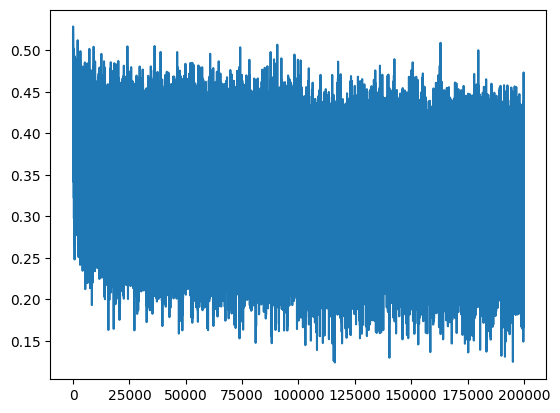

In [ ]:
plt.plot(lossi)

In [ ]:
with torch.no_grad():
    def split_loss(split):
        x, y = {
            'train': (Xtr, Ytr),
            'val': (Xdev, Ydev),
            'test': (Xte, Yte),
        }[split]
        emb = C[x] # (N, block_size, n_embd)
        emcat = emb.view(emb.shape[0], -1) # (N, block_size*n_embd)
        hpreact = emcat @ W1 + b1 # (N, n_hidden)
        # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # layer norm
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # layer norm
        h = torch.tanh(hpreact) # (N, n_hidden)
        logits = h @ W2 + b2 # (N, vocab_size)
        loss = F.cross_entropy(logits, y)
        print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train loss: 2.0666
val loss: 2.1051


**Loss Log**

*Original:*
* train: 2.1245
* val: 2.1682

*fix softmax confidently wrong:*
* train: 2.0696
* val: 2.13

*fix tanh layer too saturated at init:*
* train: 2.0356
* val: 2.1027

*use semi-principled "kaiming init" instead of hacky init:*
* train: 2.0377
* val: 2.1070

*add a batch norm layer*
* train: 2.0668
* val: 2.1048

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        emcat = emb.view(emb.shape[0], -1) # (1, block_size*n_embd)
        hpreact = emcat @ W1 + b1 # (1, n_hidden)
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # layer norm
        h = torch.tanh(hpreact) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample
        out.append(itos[ix])
        context = context[1:] + [ix] # crop and append
        if ix == 0:
            break
    print(''.join(out))

carmahzari.
harli.
jari.
reity.
salaysie.
mahnee.
delynn.
jareei.
nellara.
chaiir.
kaleigh.
ham.
jois.
quint.
salin.
alvin.
quinterri.
jaryni.
jaxen.
dus.


## Fixing the initial loss (softmax confidently wrong)

The issue at hand is that the initial loss is very high, and this because the model assigns random probabilities to the 27 characters that we are using. This gives an uneven distribution and makes the model have a high initial loss.

Instead of the random assigning we would want to have a uniform distribution at the start such that each character has the same starting probabilities.

In [ ]:
# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

## Fixing the saturated tanh

### Probem
Now, the logits are ok but another deeper problem that we have is the `h`

We can see that many values are -1 and 1 which suggest that the tanh is very active.

If all the outputs h are in flat region of -1 and 1 then the gradients flowing through the network will get destroyed at the particular layer.

### Fix

We want the `hpreact` to be close to 0.

Therefore we will change the w1 and b1

#### Before fixing

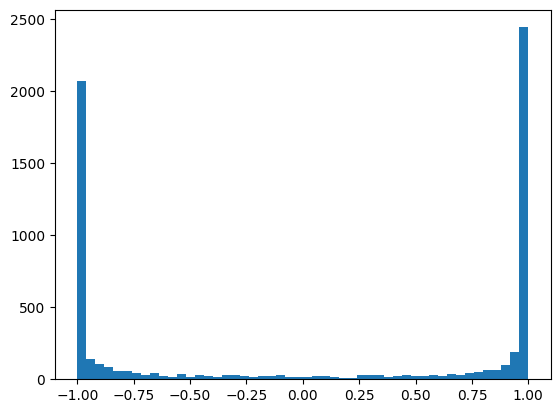

In [ ]:
# Before fixing
plt.hist(h.view(-1).tolist(), 50);

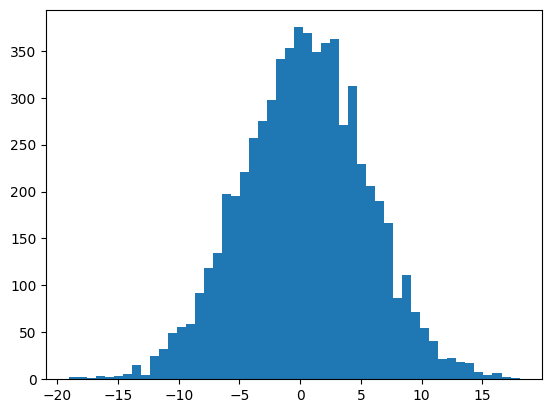

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50);

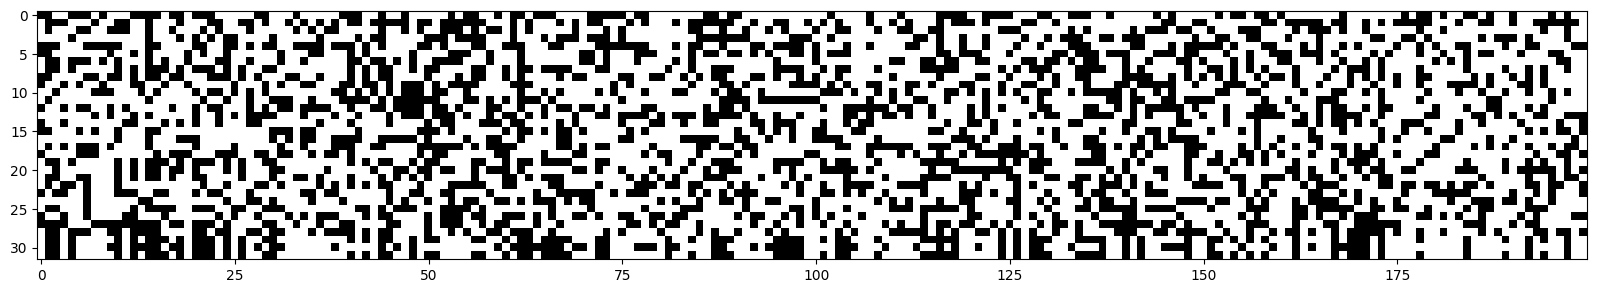

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# If any of the column has complete white this means that is a 'dead neuron'

#### After fixing

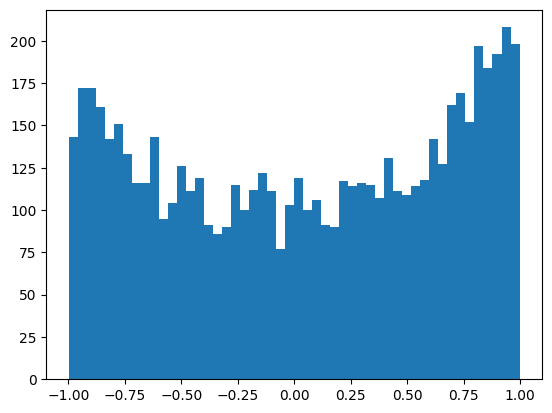

In [ ]:
plt.hist(h.view(-1).tolist(), 50);

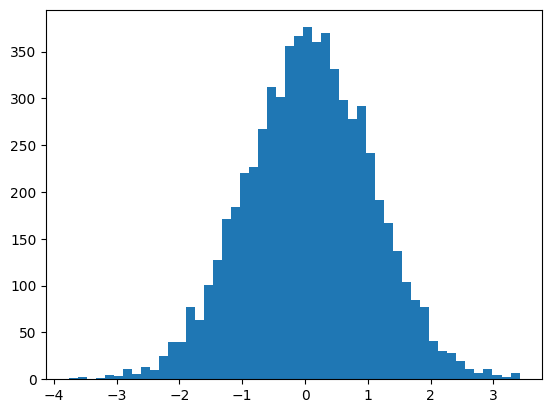

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50);

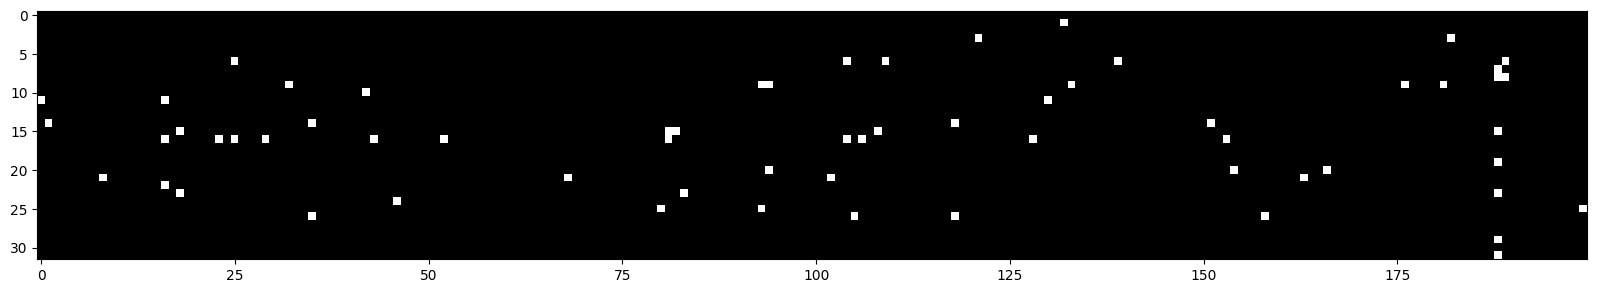

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

## Batch Normalization

We say that we have the hidden states, and we would like them to be roughly gaussian so why not take the hidden states and normalize them to be gaussian.

We are trying to make the `hpreact` roughly gaussian

What we do is:
hpreact' = (hpreact - mean of hpreact) / standard deviation of hpreact

What this does every single neurons fireing rate will be exactly unit gaussian on the example of the batch.

We don't want to force the normalization always we want to be at the starting therefore what we do is:

gama * hpreact' + beta

* gama -> batch normalization gain
* beta -> batch normalization bias

## PyTorch based code

In [34]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [35]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    # if i>=1000:
    #     break

      0/ 200000: 3.2884
  10000/ 200000: 2.3213
  20000/ 200000: 1.9293
  30000/ 200000: 1.9820
  40000/ 200000: 2.5115
  50000/ 200000: 2.3857
  60000/ 200000: 1.7832
  70000/ 200000: 2.1882
  80000/ 200000: 2.1667
  90000/ 200000: 1.7466
 100000/ 200000: 1.7549
 110000/ 200000: 1.9810
 120000/ 200000: 1.8097
 130000/ 200000: 1.7739
 140000/ 200000: 1.9657
 150000/ 200000: 1.9546
 160000/ 200000: 1.8890
 170000/ 200000: 2.3268
 180000/ 200000: 2.0125
 190000/ 200000: 1.9404


layer 2 (      Tanh): mean -0.02, std 0.71, saturated: 5.59%
layer 5 (      Tanh): mean +0.01, std 0.74, saturated: 7.22%
layer 8 (      Tanh): mean -0.00, std 0.75, saturated: 7.91%
layer 11 (      Tanh): mean +0.00, std 0.76, saturated: 7.25%
layer 14 (      Tanh): mean -0.01, std 0.77, saturated: 8.69%


Text(0.5, 1.0, 'activation distribution')

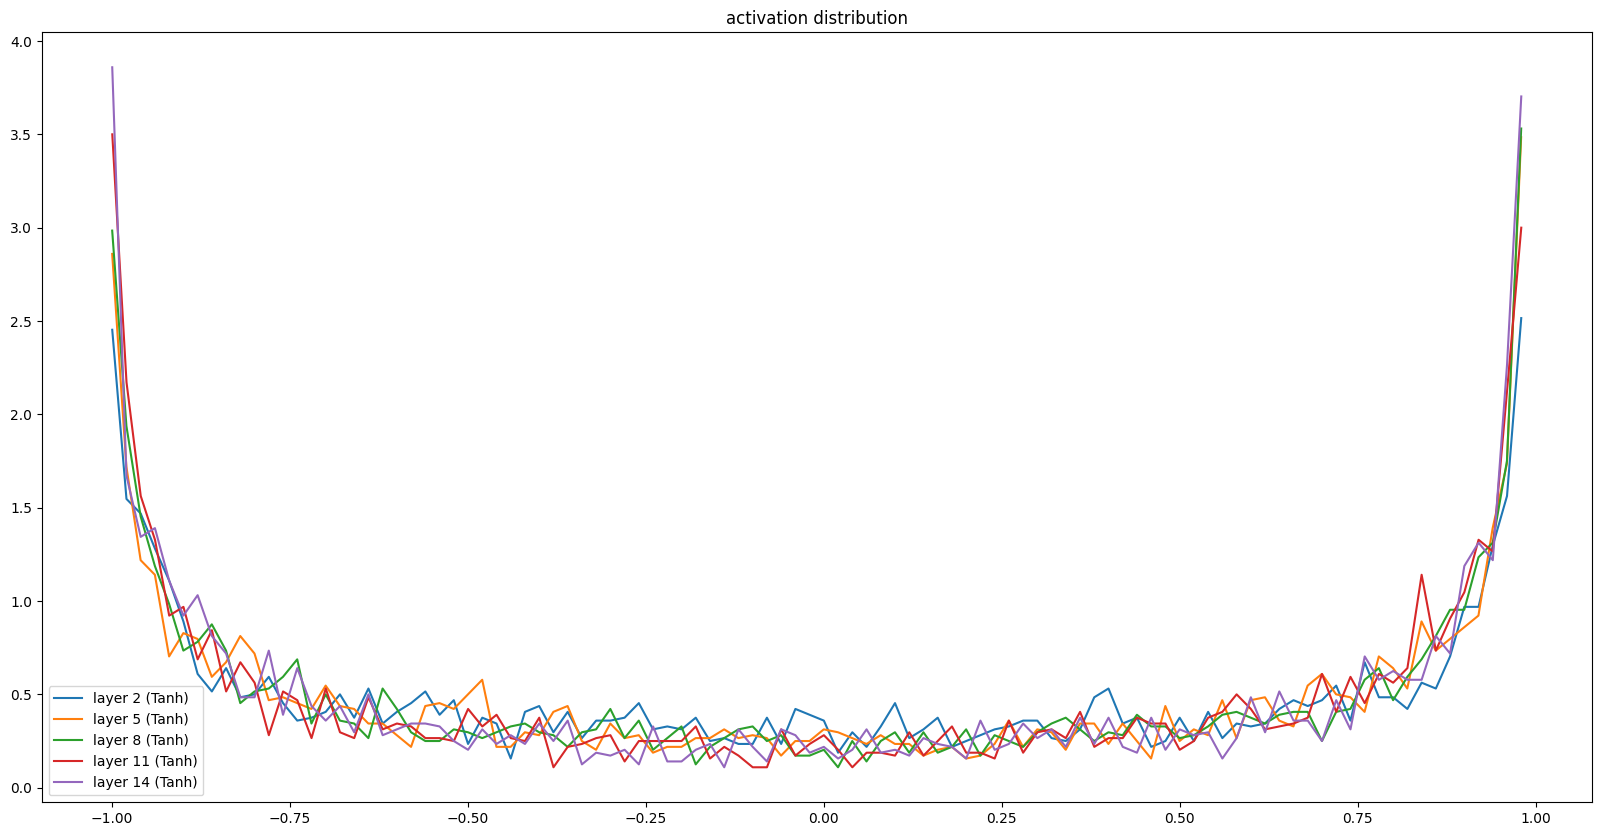

In [36]:
# visualize histograms

plt.figure(figsize=(20, 10))
legends = []
for i, layer in enumerate(layers[:-1]): # exclud the last output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, str(layer.__class__.__name__), t.mean(), t.std(), (t.abs() > 0.99).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 4.231535e-03
layer 5 (      Tanh): mean -0.000000, std 4.189608e-03
layer 8 (      Tanh): mean -0.000000, std 4.091254e-03
layer 11 (      Tanh): mean -0.000000, std 4.001494e-03
layer 14 (      Tanh): mean -0.000000, std 3.670440e-03


Text(0.5, 1.0, 'gradient distribution')

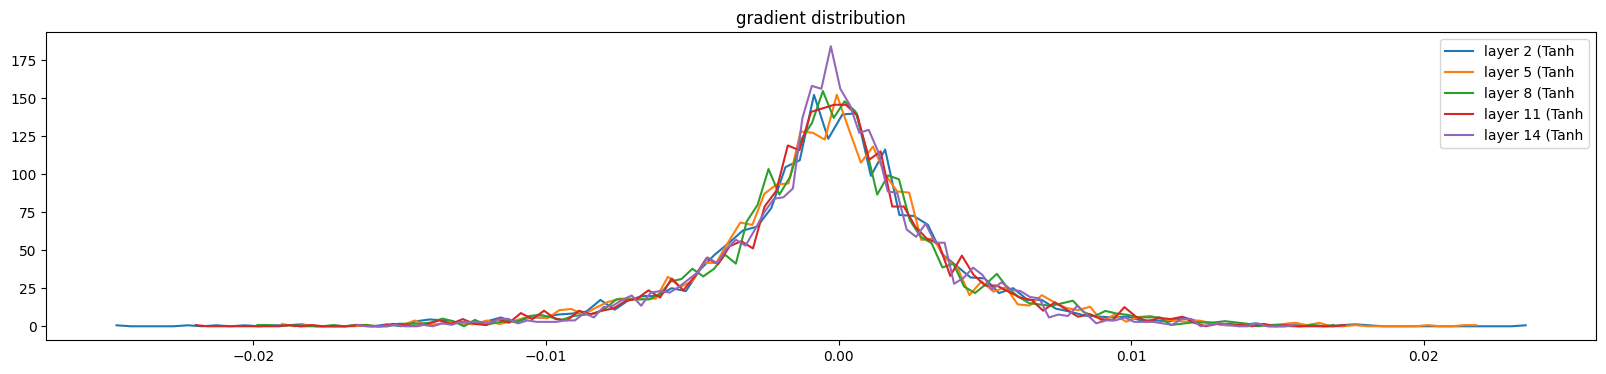

In [37]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.618900e-02 | grad:data ratio 1.480870e-02
weight  (30, 100) | mean +0.000105 | std 9.018999e-03 | grad:data ratio 2.241892e-02
weight (100, 100) | mean +0.000007 | std 6.407602e-03 | grad:data ratio 2.622508e-02
weight (100, 100) | mean +0.000011 | std 6.358244e-03 | grad:data ratio 2.615289e-02
weight (100, 100) | mean -0.000044 | std 6.179422e-03 | grad:data ratio 2.590186e-02
weight (100, 100) | mean +0.000074 | std 5.705334e-03 | grad:data ratio 2.488786e-02
weight  (100, 27) | mean -0.000003 | std 8.527710e-03 | grad:data ratio 2.581691e-02


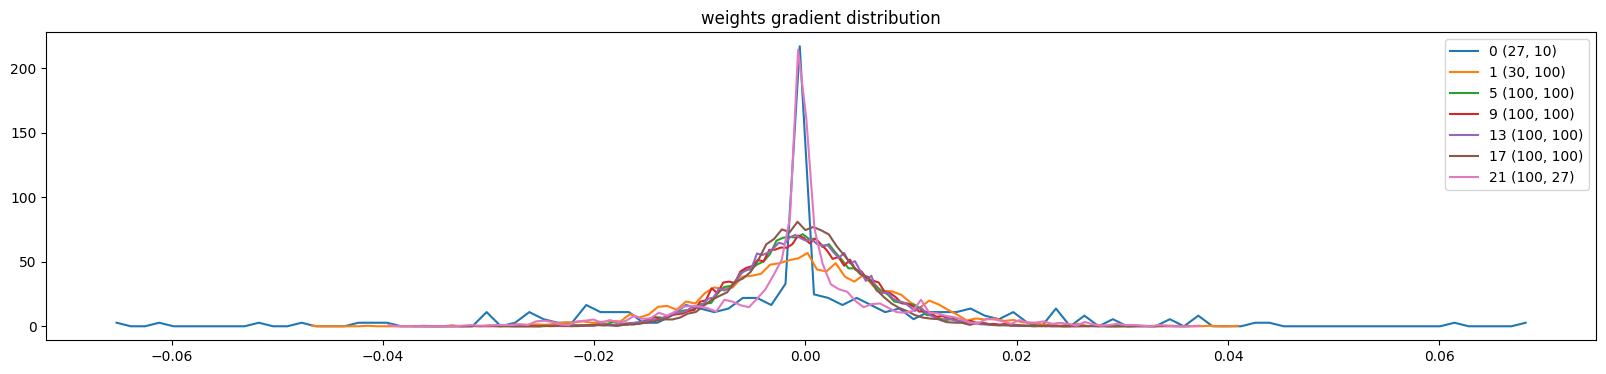

In [38]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

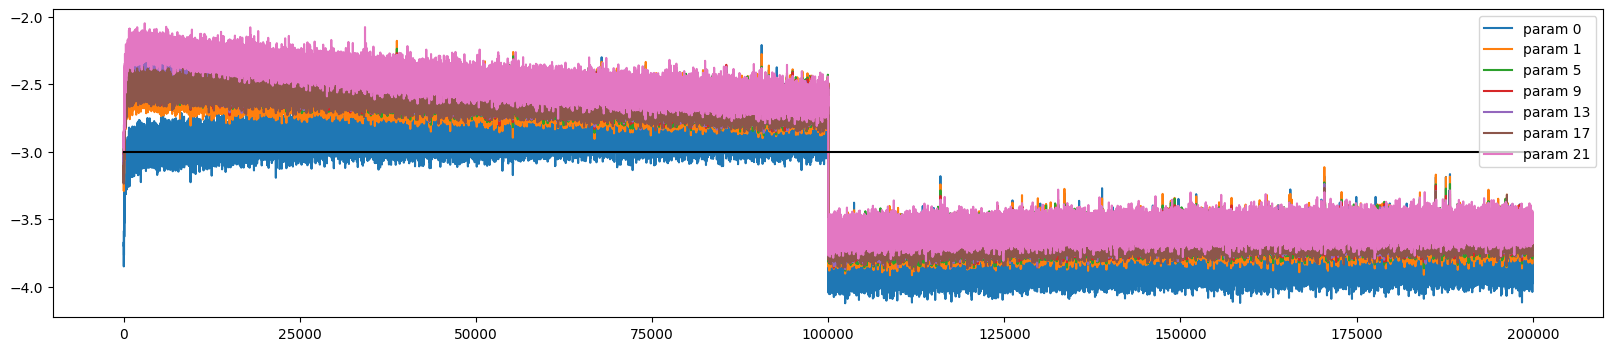

In [39]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [40]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.013727903366089
val 2.08506441116333


In [41]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
amorie.
khyrire.
reigh.
skanden.
jazhitn.
deliah.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
jord.
quinthorlin.
alvin.
quinte.
madiarynn.
jace.
pinsley.
dae.
